## Extraction rPPG Value - Face Detector

Tahapan ini merupakan tahpaan untuk mengambil dan menyimpan sinyal rPPG dari video dengan menggunakan metode FaceDetector (mengambil keseluruhan wajah)

---

Metode rPPG berasal dari pyVHR toolkit
ref: [https://github.com/phuselab/pyVHR/blob/master/pyVHR/BVP/methods.py](https://github.com/phuselab/pyVHR/blob/master/pyVHR/BVP/methods.py)

In [3]:
## Import Dependencies
import numpy as np
import mediapipe as mp
import pandas as pd
import cv2
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import scipy
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.dirname(os.getcwd()))

## Import the rPPG methods
from rppg_methods.POS import POS
from rppg_methods.LGI import LGI
from rppg_methods.GREEN import GREEN
from rppg_methods.CHROM import CHROM
from rppg_methods.OMIT import OMIT

## Face Detector Setup

Define the model

---

In [4]:
parent_dir = os.path.dirname(os.getcwd())  # Gets the parent directory (d:\UBFC-Phys)
base_model = os.path.join(parent_dir, "mediapipe_models/blaze_face_short_range.tflite")


Props setup

---

In [5]:
## Create faceDetector Object
base_options = python.BaseOptions(model_asset_path=base_model)
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode
options = FaceDetectorOptions(
    base_options=base_options,
    running_mode = VisionRunningMode.IMAGE,
)
detector = vision.FaceDetector.create_from_options(options)

### Preprocessing dan running method

In [ ]:
def extract_rppg(video_path, output_dir, subject, task, fs=35):

    # Lists to store combined RGB values
    # combined_r_signal, combined_g_signal, combined_b_signal = [], [], []
    margin_x=10
    scaling_factor=0.8
    total_frame = 0

    video_file = cv2.VideoCapture(video_path)

    while video_file.isOpened():
        ret, frame = video_file.read()

        if not ret:
            break

        # Convert image to RGB
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=image_rgb
        )

        # Face Detection
        result = detector.detect(mp_image)

        if result.detections:
            for detection in result.detections:

                ## Get the Bounding box
                bboxC = detection.bounding_box
                x, y, w, h = bboxC.origin_x, bboxC.origin_y, bboxC.width, bboxC.height

                new_x = int(x + margin_x)

                new_w = int(w * scaling_factor)
                new_h = int(h * scaling_factor)

                # Draw the rectangle
                cv2.rectangle(frame, (new_x, y), (new_x + new_w, y + new_h), (0, 255, 0), 2)

                ## Get the ROI
                face_roi = image_rgb[y:y+new_h, new_x:new_x+new_w]

                ## Calculate the Mean
                mean_rgb = cv2.mean(face_roi)[:3]
                
                # Append the combined RGB values to the respective lists
                combined_r_signal.append(mean_rgb[0])
                combined_g_signal.append(mean_rgb[1])
                combined_b_signal.append(mean_rgb[2])

        total_frame += 1

        cv2.imshow('frame', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Close the video file
    video_file.release()
    cv2.destroyAllWindows()

    ## Print the status
    print(f"Extracted {len(combined_r_signal)} frames for {subject}-{task}")

    ## Preparing RGB Signal Before Converting to rPPG
    rgb_signals = np.array([combined_r_signal, combined_g_signal, combined_b_signal])
    rgb_signals = rgb_signals.reshape(1, 3, -1)

    ## POS
    pos_signal = POS(rgb_signals, fps=fs)
    pos_signal = pos_signal.reshape(-1)

    ## Create a 2 subplot RGB (Top) and rPG Bottom
    plt.subplot(2, 1, 1)
    plt.plot(rgb_signals.reshape(3, -1)[0], color='r', label='Red Channel')
    plt.plot(rgb_signals.reshape(3, -1)[1], color='g', label='Green Channel')
    plt.plot(rgb_signals.reshape(3, -1)[2], color='b', label='Blue Channel')
    plt.title(f'RGB Signals')
    plt.xlabel('Frames')
    plt.ylabel('Intensity')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(pos_signal, color='m', label='POS rPPG Signal')
    plt.title(f'Remote Photoplethysmography (rPPG) Signal')
    plt.xlabel('Frames')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

    ## CHROM
    chrom_signal = CHROM(rgb_signals)
    chrom_signal = chrom_signal.reshape(-1)

    ## LGI
    lgi_signal = LGI(rgb_signals)
    lgi_signal = lgi_signal.reshape(-1)

    ## GREEN
    green_signal = GREEN(rgb_signals)
    green_signal = green_signal.reshape(-1)

    ## OMIT
    omit_signal = OMIT(rgb_signals)
    omit_signal = omit_signal.reshape(-1)

    # ## Save the RPPG as .npy
    # pos_path = os.path.join(output_dir, f"{subject}_{task}-POS-rppg.npy")
    # np.save(pos_path, pos_signal)
    # print(f"Saved POS signal to: {pos_path}")

    # chrom_path = os.path.join(output_dir, f"{subject}_{task}-CHROM-rppg.npy")
    # np.save(chrom_path, chrom_signal)
    # print(f"Saved CHROM signal to: {chrom_path}")

    # lgi_path = os.path.join(output_dir, f"{subject}_{task}-LGI-rppg.npy")
    # np.save(lgi_path, lgi_signal)
    # print(f"Saved LGI signal to: {lgi_path}")

    # green_path = os.path.join(output_dir, f"{subject}_{task}-GREEN-rppg.npy")
    # np.save(green_path, green_signal)
    # print(f"Saved GREEN signal to: {green_path}")

    # omit_path = os.path.join(output_dir, f"{subject}_{task}-OMIT-rppg.npy")
    # np.save(omit_path, omit_signal)
    # print(f"Saved OMIT signal to: {omit_path}")

### Main method 
Iterate the entire subject to convert RGB Signals from video to npy file format

In [9]:
# subjects = ["s41","s42", "s43", "s44", "s45", "s46", "s47", "s48", "s49", "s50"]
subjects = ["s51"]
tasks = ["T1"]
parent_dir = os.path.dirname(os.getcwd())  # Gets the parent directory (d:\UBFC-Phys)

for subject in subjects:
    if not os.path.exists(f"{parent_dir}/{subject}"):
        print(f"Subject {subject} not found, skipping")
    
    for task in tasks:
        video_path = f"{parent_dir}/{subject}/vid_{subject}_{task}.avi"
        print(video_path)
        if os.path.exists(video_path):
            extract_rppg(
                video_path=video_path,
                output_dir=f"{subject}",
                subject=subject,
                task=task,
                fs=35
            )

        

d:\UBFC-Phys/s51/vid_s51_T1.avi


UnboundLocalError: cannot access local variable 'combined_r_signal' where it is not associated with a value

d:\UBFC-Phys/s51/vid_s51_T1.avi
Extracted 1000 frames for s51-T1


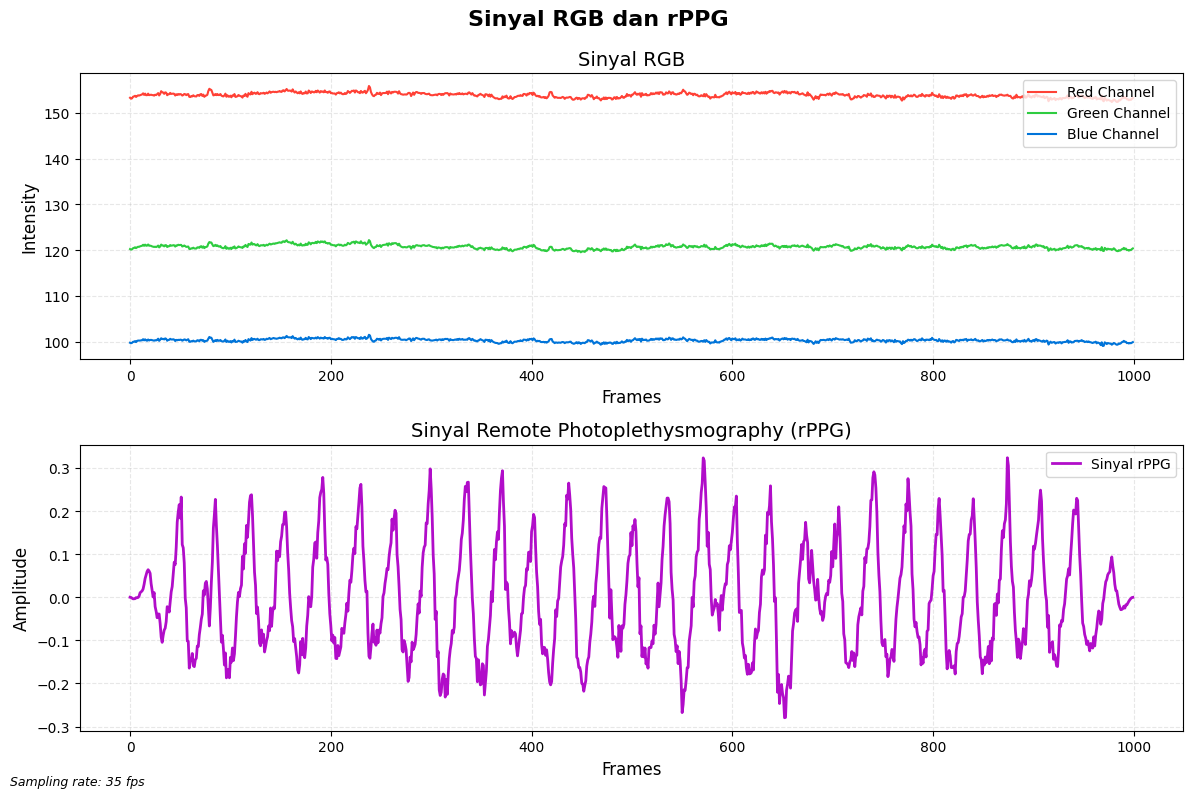

In [16]:
# subjects = ["s41","s42", "s43", "s44", "s45", "s46", "s47", "s48", "s49", "s50"]
subjects = ["s51"]
tasks = ["T1"]
parent_dir = os.path.dirname(os.getcwd())  # Gets the parent directory (d:\UBFC-Phys)

for subject in subjects:
    if not os.path.exists(f"{parent_dir}/{subject}"):
        print(f"Subject {subject} not found, skipping")
    
    for task in tasks:
        video_path = f"{parent_dir}/{subject}/vid_{subject}_{task}.avi"
        print(video_path)
        if os.path.exists(video_path):

            # Lists to store combined RGB values
            # combined_r_signal, combined_g_signal, combined_b_signal = [], [], []
            # margin_x=10
            # scaling_factor=0.8
            # total_frame = 0

            # video_file = cv2.VideoCapture(video_path)

            # while video_file.isOpened():
            #     ret, frame = video_file.read()

            #     # if frame is 1000 frames, break
            #     if total_frame == 1000:
            #         break

            #     if not ret:
            #         break

            #     # Convert image to RGB
            #     image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            #     mp_image = mp.Image(
            #         image_format=mp.ImageFormat.SRGB,
            #         data=image_rgb
            #     )

            #     # Face Detection
            #     result = detector.detect(mp_image)

            #     if result.detections:
            #         for detection in result.detections:

            #             ## Get the Bounding box
            #             bboxC = detection.bounding_box
            #             x, y, w, h = bboxC.origin_x, bboxC.origin_y, bboxC.width, bboxC.height

            #             new_x = int(x + margin_x)

            #             new_w = int(w * scaling_factor)
            #             new_h = int(h * scaling_factor)

            #             # Draw the rectangle
            #             cv2.rectangle(frame, (new_x, y), (new_x + new_w, y + new_h), (0, 255, 0), 2)

            #             ## Get the ROI
            #             face_roi = image_rgb[y:y+new_h, new_x:new_x+new_w]

            #             ## Calculate the Mean
            #             mean_rgb = cv2.mean(face_roi)[:3]
                        
            #             # Append the combined RGB values to the respective lists
            #             combined_r_signal.append(mean_rgb[0])
            #             combined_g_signal.append(mean_rgb[1])
            #             combined_b_signal.append(mean_rgb[2])

            #     total_frame += 1

            #     cv2.imshow('frame', frame)
            #     if cv2.waitKey(1) & 0xFF == ord('q'):
            #         break

            # # Close the video file
            # video_file.release()
            # cv2.destroyAllWindows()

            ## Print the status
            print(f"Extracted {len(combined_r_signal)} frames for {subject}-{task}")

            ## Preparing RGB Signal Before Converting to rPPG
            rgb_signals = np.array([combined_r_signal, combined_g_signal, combined_b_signal])
            rgb_signals = rgb_signals.reshape(1, 3, -1)
            fs = 35

            ## POS
            pos_signal = POS(rgb_signals, fps=fs)
            pos_signal = pos_signal.reshape(-1)

            ## Create a 2 subplot RGB (Top) and rPG Bottom
            # Create a more polished plot for presentation
            plt.figure(figsize=(12, 8), dpi=100)

            # Add a figure title
            plt.suptitle(f"Sinyal RGB dan rPPG", fontsize=16, fontweight='bold')

            # Top subplot - RGB signals
            ax1 = plt.subplot(2, 1, 1)
            ax1.plot(rgb_signals.reshape(3, -1)[0], color='#FF4136', label='Red Channel', linewidth=1.5)
            ax1.plot(rgb_signals.reshape(3, -1)[1], color='#2ECC40', label='Green Channel', linewidth=1.5)
            ax1.plot(rgb_signals.reshape(3, -1)[2], color='#0074D9', label='Blue Channel', linewidth=1.5)
            ax1.set_title('Sinyal RGB', fontsize=14)
            ax1.set_xlabel('Frames', fontsize=12)
            ax1.set_ylabel('Intensity', fontsize=12)
            ax1.grid(True, alpha=0.3, linestyle='--')
            ax1.legend(loc='upper right', frameon=True)

            # Bottom subplot - rPPG signal
            ax2 = plt.subplot(2, 1, 2)
            ax2.plot(pos_signal, color='#B10DC9', label='Sinyal rPPG', linewidth=2)
            ax2.set_title('Sinyal Remote Photoplethysmography (rPPG)', fontsize=14)
            ax2.set_xlabel('Frames', fontsize=12)
            ax2.set_ylabel('Amplitude', fontsize=12)
            ax2.grid(True, alpha=0.3, linestyle='--')
            ax2.legend(loc='upper right', frameon=True)

            # Highlight pulse peaks if needed
            # from scipy.signal import find_peaks
            # peaks, _ = find_peaks(pos_signal, distance=20)
            # ax2.plot(peaks, pos_signal[peaks], "x", color='red', markersize=8)

            # Add note about sampling rate
            plt.figtext(0.01, 0.01, f"Sampling rate: {fs} fps", fontsize=9, style='italic')

            # Adjust layout
            plt.tight_layout()
            plt.subplots_adjust(top=0.9, hspace=0.3)
            plt.show()

            ## CHROM
            chrom_signal = CHROM(rgb_signals)
            chrom_signal = chrom_signal.reshape(-1)

            ## LGI
            lgi_signal = LGI(rgb_signals)
            lgi_signal = lgi_signal.reshape(-1)

            ## GREEN
            green_signal = GREEN(rgb_signals)
            green_signal = green_signal.reshape(-1)

            ## OMIT
            omit_signal = OMIT(rgb_signals)
            omit_signal = omit_signal.reshape(-1)

            # ## Save the RPPG as .npy
            # pos_path = os.path.join(output_dir, f"{subject}_{task}-POS-rppg.npy")
            # np.save(pos_path, pos_signal)
            # print(f"Saved POS signal to: {pos_path}")

            # chrom_path = os.path.join(output_dir, f"{subject}_{task}-CHROM-rppg.npy")
            # np.save(chrom_path, chrom_signal)
            # print(f"Saved CHROM signal to: {chrom_path}")

            # lgi_path = os.path.join(output_dir, f"{subject}_{task}-LGI-rppg.npy")
            # np.save(lgi_path, lgi_signal)
            # print(f"Saved LGI signal to: {lgi_path}")

            # green_path = os.path.join(output_dir, f"{subject}_{task}-GREEN-rppg.npy")
            # np.save(green_path, green_signal)
            # print(f"Saved GREEN signal to: {green_path}")

            # omit_path = os.path.join(output_dir, f"{subject}_{task}-OMIT-rppg.npy")
            # np.save(omit_path, omit_signal)
            # print(f"Saved OMIT signal to: {omit_path}")

                